In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import glob
import time
import gc
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#set TORCH_HOME=E:\MS Thesis\codes\DSTCT-master\code\weights
#os.environ['TORCH_HOME'] = r'E:\New_Project\CoronaryDominanceDataset\MultiTaskingLearning\weights'
os.environ['TORCH_HOME'] = r'E:\MS Thesis\codes\DSTCT-master\code\weights'

# DATA PREPARATION

In [1]:
import os
import shutil
import glob
from tqdm import tqdm

In [26]:
filename = "Study00605_RCA_1.1.11.111111.11.18779744146411007918222512466842968.1.1_frame_1.png"
# Split from the last underscore to get 'frame_1.png'
frame_part = filename.split("_")[-2] + "_" + filename.split("_")[-1]
print(frame_part)


frame_1.png


In [58]:
main_dir = r'E:\New_Project\CoronaryDominanceDataset\MultiTaskingLearning\Occlusion\RCA\Data'
save_dir = r'E:\New_Project\CoronaryDominanceDataset\MultiTaskingLearning\OCCLUSION_DATA\RCA\Data'

for partition in os.listdir(main_dir):
    partition_path = os.path.join(main_dir, partition)
    print(f"{partition}..........................................................................................................")
    for label in os.listdir(os.path.join(partition_path,'fold_1')):
        print(f"Processing label: {label}=========================================================================================")
        label_path = os.path.join(partition_path, 'fold_1', label)
        videos = []
        for video in os.listdir(label_path):
            video_path = os.path.join(label_path, video)
            video_name = video.split('_frame_')[0]
            videos.append(video_name)
        videos = list(set(videos))
        #print(len(videos))
        count = 0
        for video_id in videos:
            count += 1
            print(f"{count}. {video_id}")
            #print(label_path)
            search_pattern = os.path.join(label_path, f"{video_id}_frame_*.png")
            matching_files = glob.glob(search_pattern)
            print(f"Found {len(matching_files)} matching files for video ID: {video_id}")
            #print(matching_files)
            for frame_path in tqdm(matching_files):
                #print(frame_path)
                
                dest = os.path.join(save_dir, partition, 'fold_1', label, video_id)
                frame_name = os.path.basename(frame_path)
                frame_part = frame_name.split("_")[-2] + "_" + frame_name.split("_")[-1]
            
                os.makedirs(dest, exist_ok=True)
                shutil.copy(frame_path, os.path.join(dest, frame_part))
        print(f"======================================================================================================================")
    print(f"...........................................................................................................................")
    print(f"...........................................................................................................................")

               
        
        

Test..........................................................................................................
Processing label: nonoccluded=========================================================================================
1. Study00605_RCA_1.1.11.111111.11.18779744146411007918222512466842968.1.1
Found 57 matching files for video ID: Study00605_RCA_1.1.11.111111.11.18779744146411007918222512466842968.1.1


  0%|          | 0/57 [00:00<?, ?it/s]

100%|██████████| 57/57 [00:00<00:00, 591.76it/s]


2. Study00605_RCA_1.1.11.111111.11.93591588409503069155491156635818206.1.1
Found 52 matching files for video ID: Study00605_RCA_1.1.11.111111.11.93591588409503069155491156635818206.1.1


100%|██████████| 52/52 [00:00<00:00, 124.79it/s]


...

31. Study00887_RCA_1.1.11.111111.11.21908323407236713331668331089192507.1.1
Found 144 matching files for video ID: Study00887_RCA_1.1.11.111111.11.21908323407236713331668331089192507.1.1


100%|██████████| 144/144 [00:01<00:00, 135.04it/s]


32. Study00945_RCA_1.1.11.111111.11.37646481731232524285369480163094794.1.1
Found 29 matching files for video ID: Study00945_RCA_1.1.11.111111.11.37646481731232524285369480163094794.1.1


100%|██████████| 29/29 [00:00<00:00, 75.05it/s]

...........................................................................................................................
...........................................................................................................................


In [9]:
train_dir = r'E:\New_Project\CoronaryDominanceDataset\MultiTaskingLearning\OCCLUSION_DATA\RCA\Data\Train\fold_1'
occ = {}
non_occ = {}
for label in os.listdir(train_dir):
    print(label)
    count = 0
    total_frames = 0
    for video in os.listdir(os.path.join(train_dir,label)):
        count+=1
        frames = os.listdir(os.path.join(train_dir,label,video))
        total_frames+=len(frames)
        if label == 'nonoccluded':
            non_occ[video] = len(frames)
        else:
            occ[video] = len(frames)

        print(f"{count}. {video} =====> frames: {len(frames)}")
    print()
    print("================================================================")
    print(f"Total {label} frames: {total_frames}")
    

nonoccluded
1. Study00051_RCA_1.1.11.111111.11.72135043137563064187025127114948188.1.1 =====> frames: 54
2. Study00051_RCA_1.1.11.111111.11.78936505544854248366542201689106501.1.1 =====> frames: 46
3. Study00052_RCA_1.1.11.111111.11.49484724493505060702178020792122870.1.1 =====> frames: 63
4. Study00052_RCA_1.1.11.111111.11.80325256478740413678549772517773081.1.1 =====> frames: 54
5. Study00053_RCA_1.1.11.111111.11.13378649666699690727340923781597914.1.1 =====> frames: 31
6. Study00053_RCA_1.1.11.111111.11.17233410029165967050354379367696029.1.1 =====> frames: 30
7. Study00054_RCA_1.1.11.111111.11.32406264021479347408639922720567504.1.1 =====> frames: 47
8. Study00054_RCA_1.1.11.111111.11.89509636041927906017613976572102315.1.1 =====> frames: 56
9. Study00055_RCA_1.1.11.111111.11.55395861942556135052574104622527655.1.1 =====> frames: 96
10. Study00055_RCA_1.1.11.111111.11.82600993561916505457057236743198730.1.1 =====> frames: 51
11. Study00056_RCA_1.1.11.111111.11.270469945800481890385

In [11]:
print(len(occ))
print(len(non_occ))

135
172


In [13]:
total_occ_frames = sum(occ.values())
total_nonocc_frames = sum(non_occ.values())

print(f"Occlusion ==>  Videos: {len(occ)}, Frames: {total_occ_frames}")
print(f"Non-Occlusion ==>  Videos: {len(non_occ)}, Frames: {total_nonocc_frames}")


Occlusion ==>  Videos: 135, Frames: 7392
Non-Occlusion ==>  Videos: 172, Frames: 8212


In [15]:
max_occ_video = max(occ, key=occ.get)
max_nonocc_video = max(non_occ, key=non_occ.get)

min_occ_video = min(occ, key=occ.get)
min_nonocc_video = min(non_occ, key=non_occ.get)

print(f"Max occluded video: {max_occ_video} with {occ[max_occ_video]} frames")
print(f"Max non-occluded video: {max_nonocc_video} with {non_occ[max_nonocc_video]} frames")
print()
print(f"Min occluded video: {min_occ_video} with {occ[min_occ_video]} frames")
print(f"Min non-occluded video: {min_nonocc_video} with {non_occ[min_nonocc_video]} frames")

Max occluded video: Study00981_RCA_1.1.11.111111.11.96471112737086557320220742965892561.1.1 with 126 frames
Max non-occluded video: Study00079_RCA_1.1.11.111111.11.50037805267132907480089492483213039.1.1 with 118 frames

Min occluded video: Study00885_RCA_1.1.11.111111.11.26274744648531623143801171006291805.1.1 with 19 frames
Min non-occluded video: Study00107_RCA_1.1.11.111111.11.65785966352984949163110618703346645.1.1 with 20 frames


# DATALOADER

In [3]:
class VideoFrameDataset(Dataset):
    """
    A PyTorch Dataset for loading video frames for classification.
    """
    def __init__(self, data_dir, sequence_length=30, transform=None, is_grayscale=False):
        self.data_dir = data_dir
        self.sequence_length = sequence_length
        self.transform = transform
        self.is_grayscale = is_grayscale
        self.classes = ['nonoccluded', 'occluded']
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.video_samples = self._find_videos()

    def _find_videos(self):
        samples = []
        if not os.path.exists(self.data_dir):
            print(f"Error: Data directory not found at {self.data_dir}")
            return samples
        for class_name in self.classes:
            class_dir = os.path.join(self.data_dir, class_name)
            if not os.path.isdir(class_dir):
                print(f"Warning: Directory not found for class '{class_name}': {class_dir}")
                continue
            for video_folder in os.listdir(class_dir):
                video_path = os.path.join(class_dir, video_folder)
                if os.path.isdir(video_path):
                    samples.append((video_path, self.class_to_idx[class_name]))
        print(f"Found {len(samples)} videos in {self.data_dir}.")
        return samples

    def __len__(self):
        return len(self.video_samples)

    def __getitem__(self, idx):
        video_path, label = self.video_samples[idx]
        frame_paths = sorted(glob.glob(os.path.join(video_path, '*.png')), key=lambda x: int(os.path.basename(x).split('_')[1].split('.')[0]))
        total_frames = len(frame_paths)
        if total_frames == 0:
            num_channels = 1 if self.is_grayscale else 3
            return torch.zeros(self.sequence_length, num_channels, 224, 224), label

        indices = np.linspace(0, total_frames - 1, self.sequence_length, dtype=int)
        frames = []
        for i in indices:
            frame_path = frame_paths[i]
            try:
                # Handle grayscale or RGB
                img_mode = 'L' if self.is_grayscale else 'RGB'
                image = Image.open(frame_path).convert(img_mode)
                if self.transform:
                    image = self.transform(image)
                frames.append(image)
            except Exception as e:
                print(f"Error loading frame {frame_path}: {e}")
                num_channels = 1 if self.is_grayscale else 3
                frames.append(torch.zeros(num_channels, 224, 224))

        frames_tensor = torch.stack(frames)
        return frames_tensor, label

# MODEL

In [4]:
class VideoClassifier(nn.Module):
    """
    A flexible video classification model that allows for different backbones and
    sequential models, and handles grayscale input.
    """
    def __init__(self, num_classes, backbone_name='resnet18', input_channels=1,
                 sequential_model_type='lstm', hidden_dim=512,
                 num_sequential_layers=2, bidirectional=True, dropout=0.5,
                 n_transformer_heads=8, n_transformer_layers=4,use_checkpointing=False):
        super().__init__()

        self.backbone_name = backbone_name
        self.sequential_model_type = sequential_model_type.lower()

        # --- 1. Get CNN Backbone and Feature Dimension ---
        self.feature_extractor, self.feature_dim = self._get_backbone(backbone_name, input_channels,use_checkpointing)
        # Add a pooling layer to handle spatial feature maps from CNNs
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # --- 2. Define Sequential Model ---
        if self.sequential_model_type == 'lstm' or self.sequential_model_type == 'gru':
            if self.sequential_model_type == 'lstm':
                self.sequential_model = nn.LSTM(
                    input_size=self.feature_dim, hidden_size=hidden_dim,
                    num_layers=num_sequential_layers, batch_first=True,
                    dropout=dropout if num_sequential_layers > 1 else 0,
                    bidirectional=bidirectional
                )
            else: # GRU
                self.sequential_model = nn.GRU(
                    input_size=self.feature_dim, hidden_size=hidden_dim,
                    num_layers=num_sequential_layers, batch_first=True,
                    dropout=dropout if num_sequential_layers > 1 else 0,
                    bidirectional=bidirectional
                )
            temporal_feature_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        elif self.sequential_model_type == 'transformer':
            self.pos_encoder = nn.Parameter(torch.zeros(1, 100, self.feature_dim)) # Max 100 frames
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=self.feature_dim, nhead=n_transformer_heads,
                dim_feedforward=hidden_dim, dropout=dropout, batch_first=True
            )
            self.sequential_model = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
            temporal_feature_dim = self.feature_dim
        
        else:
            raise ValueError(f"Unsupported sequential model type: {sequential_model_type}")

        # --- 3. Define Classifier Head ---
        self.classifier = nn.Sequential(
            nn.Linear(temporal_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def _get_backbone(self, name, input_channels,use_checkpointing):
        """Loads a pre-trained backbone and modifies it for grayscale if needed."""
        print(f"Loading backbone: {name}")
        # Load pre-trained model
        if name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            feature_dim = model.fc.in_features
            if input_channels == 1:
                model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            extractor = nn.Sequential(*list(model.children())[:-1])
        elif name == 'densenet121':
            # DenseNet has a built-in memory efficient mode that uses checkpointing
            model = models.densenet121(weights='DEFAULT', memory_efficient=use_checkpointing)
            if use_checkpointing: print("Using memory-efficient checkpointing for DenseNet.")
            feature_dim = model.classifier.in_features
            if input_channels == 1:
                model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            extractor = model.features
        elif name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
            feature_dim = model.classifier[1].in_features
            if input_channels == 1:
                model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            extractor = model.features
        elif name == 'mobilenet_v2':
            model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
            feature_dim = model.classifier[1].in_features
            if input_channels == 1:
                model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            extractor = model.features
        elif name == 'vit_b_16':
            model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
            feature_dim = model.heads.head.in_features
            if input_channels == 1:
                 # Modify the patch embedding layer
                old_conv = model.conv_proj
                model.conv_proj = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride)
            # For ViT, the "extractor" is the whole model except the final classification head
            extractor = nn.Sequential(*list(model.children())[:-1])
        else:
            raise ValueError(f"Unsupported backbone: {name}")
        
        print(f"Backbone '{name}' loaded. Feature dimension: {feature_dim}. Input channels: {input_channels}.")
        return extractor, feature_dim

    def forward(self, x):
        batch_size, seq_length, c, h, w = x.shape
        x_reshaped = x.view(batch_size * seq_length, c, h, w)
        
        features = self.feature_extractor(x_reshaped)
        
        #if self.backbone_name == 'vit_b_16':
            # ViT's output from the sequential block is already (N*S, D)
            #features = features.view(batch_size, seq_length, -1)
        #if 'densenet' in self.backbone_name:
        features = self.pool(features)
        #else:
        # Other CNNs need flattening
        features = features.view(batch_size, seq_length, self.feature_dim)

        # --- Temporal Modeling ---
        if self.sequential_model_type == 'transformer':
            # Add positional encoding
            features += self.pos_encoder[:, :seq_length, :]
            temporal_out = self.sequential_model(features)
            # Use the output of the [CLS] token equivalent, which is the mean of all frame features
            temporal_out = temporal_out.mean(dim=1)
        else: # LSTM or GRU
            temporal_out, _ = self.sequential_model(features)
            # We take the output of the last time step for classification
            temporal_out = temporal_out[:, -1, :]
        
        logits = self.classifier(temporal_out)
        return logits

# TRAINING

In [5]:
def train_model(model, train_dl, val_dl, criterion, optimizer, scheduler, 
                n_epochs, checkpoint_path, device, patience=10, 
                use_amp=True, accumulation_steps=4):
    history, best_val_loss, epochs_no_improve = [], float('inf'), 0
    overall_start_time = time.time()
    
    # Initialize Gradient Scaler for Automatic Mixed Precision
    scaler = torch.amp.GradScaler('cuda')

    print(f"Starting training on {device} for {n_epochs} epochs...")
    print(f"Using AMP: {use_amp}, Gradient Accumulation Steps: {accumulation_steps}")
    print("==============================================================")

    for epoch in range(n_epochs):
        epoch_start_time = time.time()
        
        # --- Training Phase ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        optimizer.zero_grad() # Zero gradients at the start of the epoch
        
        for i, (videos, labels) in enumerate(tqdm(train_dl, desc=f"Epoch {epoch+1}/{n_epochs} [Train]")):
            videos, labels = videos.to(device), labels.to(device)
            
            # Automatic Mixed Precision context manager
            with torch.amp.autocast("cuda"):
                outputs = model(videos)
                loss = criterion(outputs, labels)
                # Scale loss for accumulation
                loss = loss / accumulation_steps
            
            # Scale gradients and perform backward pass
            scaler.scale(loss).backward()
            
            # --- Gradient Accumulation Step ---
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            # --- Statistics Calculation ---
            train_loss += loss.item() * videos.size(0) * accumulation_steps # Unscale loss for logging
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            del videos, labels, outputs, loss, predicted
        
        avg_train_loss = train_loss / len(train_dl.dataset)
        avg_train_acc = train_correct / train_total

        # --- Validation Phase ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for videos, labels in tqdm(val_dl, desc=f"Epoch {epoch+1}/{n_epochs} [Val]  "):
                videos, labels = videos.to(device), labels.to(device)
                with torch.amp.autocast("cuda"):
                    outputs = model(videos)
                    loss = criterion(outputs, labels)
                val_loss += loss.item() * videos.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                del videos, labels, outputs, loss, predicted

        avg_val_loss = val_loss / len(val_dl.dataset)
        avg_val_acc = val_correct / val_total
        
        if device.type == 'cuda': torch.cuda.empty_cache()
        gc.collect()

        epoch_duration = time.time() - epoch_start_time
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.4f}")

        history.append({'epoch': epoch+1, 'train_loss': avg_train_loss, 'train_acc': avg_train_acc, 'val_loss': avg_val_loss, 'val_acc': avg_val_acc})
        
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss, epochs_no_improve = avg_val_loss, 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  -> Val loss improved. Saved best model.")
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs.")
            break
            
    print(f"Training complete in {(time.time() - overall_start_time)/60:.2f} minutes.")
    model.load_state_dict(torch.load(checkpoint_path))
    return model, pd.DataFrame(history)

In [6]:
BASE_DATA_DIR = r'E:\Morshedul\CoronarDominance\content\OCCLUSION_DATA\RCA\Data'
FOLD = 'fold_1'
TRAIN_DIR = os.path.join(BASE_DATA_DIR, 'Train', FOLD)
VAL_DIR = os.path.join(BASE_DATA_DIR, 'Val', FOLD)
#TEST_DIR = os.path.join(BASE_DATA_DIR, 'Test', FOLD)
OUTPUT_DIR = r'E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\training_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'mobilenetv2_LSTM_best_model.pth')
#PLOT_PATH = os.path.join(OUTPUT_DIR, 'training_curves.png')

In [7]:
# Model Architecture Settings
# BACKBONE: 'resnet18', 'densenet121', 'efficientnet_b0', 'mobilenet_v2', 'vit_b_16'
BACKBONE_NAME = 'mobilenet_v2' 
# SEQUENTIAL_MODEL: 'lstm', 'gru', 'transformer'
SEQUENTIAL_MODEL = 'lstm'
IS_GRAYSCALE = True # Set to True for 1-channel grayscale images

# Hyperparameters
SEQUENCE_LENGTH = 15
BATCH_SIZE = 8 # Smaller batch size for local testing
NUM_EPOCHS = 80 # Fewer epochs for a quick test run
LEARNING_RATE = 1e-4
PATIENCE = 100
NUM_CLASSES = 2
NUM_WORKERS = 0 # Adjust based on your system's capabilities

In [8]:
# --- MEMORY OPTIMIZATION SETTINGS ---
# Use checkpointing for memory-intensive backbones like DenseNet
USE_CHECKPOINTING = True if 'densenet' in BACKBONE_NAME else False
# Use Automatic Mixed Precision (AMP) to reduce memory and speed up training
USE_AMP = True
# Accumulate gradients over N steps to simulate a larger batch size
ACCUMULATION_STEPS = 2 # Effective batch size will be BATCH_SIZE * ACCUMULATION_STEPS (4*4=16)

In [9]:
MEAN, STD = 0.5461, 0.1453
data_transforms = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[MEAN], std=[STD])
    ])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Dataloaders ---
print("\nSetting up datasets...")
input_channels = 1 if IS_GRAYSCALE else 3
train_dataset = VideoFrameDataset(TRAIN_DIR, SEQUENCE_LENGTH, data_transforms, IS_GRAYSCALE)
val_dataset = VideoFrameDataset(VAL_DIR, SEQUENCE_LENGTH, data_transforms, IS_GRAYSCALE)


train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
    

Using device: cuda

Setting up datasets...
Found 307 videos in E:\Morshedul\CoronarDominance\content\OCCLUSION_DATA\RCA\Data\Train\fold_1.
Found 73 videos in E:\Morshedul\CoronarDominance\content\OCCLUSION_DATA\RCA\Data\Val\fold_1.
Train samples: 307, Val samples: 73


In [10]:
print("\nInitializing model...")
model = VideoClassifier(
    num_classes=2,
    backbone_name=BACKBONE_NAME,
    input_channels=input_channels,
    sequential_model_type=SEQUENTIAL_MODEL,
    hidden_dim = 128,
    num_sequential_layers = 5,
    bidirectional=False,
    use_checkpointing = USE_CHECKPOINTING
).to(device)


Initializing model...
Loading backbone: mobilenet_v2
Backbone 'mobilenet_v2' loaded. Feature dimension: 1280. Input channels: 1.


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)


In [12]:
model, history = train_model(
    model = model, 
    train_dl= train_loader, 
    val_dl = val_loader, 
    criterion = criterion, 
    optimizer = optimizer, 
    scheduler = scheduler,
    n_epochs = NUM_EPOCHS, checkpoint_path = CHECKPOINT_PATH, device = device, patience = PATIENCE
)

Starting training on cuda for 80 epochs...
Using AMP: True, Gradient Accumulation Steps: 4


Epoch 1/80 [Val]  : 100%|█████████████████████████████████| 10/10 [00:14<00:00,  1.47s/it]


Epoch 1/80 | Train Loss: 0.6974, Acc: 0.4430 | Val Loss: 0.6942, Acc: 0.4384
  -> Val loss improved. Saved best model.


Epoch 2/80 [Val]  : 100%|█████████████████████████████████| 10/10 [00:11<00:00,  1.15s/it]


Epoch 2/80 | Train Loss: 0.6933, Acc: 0.4951 | Val Loss: 0.6929, Acc: 0.5616
  -> Val loss improved. Saved best model.


...

Epoch 78/80 | Train Loss: 0.1177, Acc: 0.9674 | Val Loss: 0.3547, Acc: 0.8904


Epoch 79/80 [Val]  : 100%|████████████████████████████████| 10/10 [00:13<00:00,  1.35s/it]


Epoch 79/80 | Train Loss: 0.1112, Acc: 0.9772 | Val Loss: 0.3501, Acc: 0.8904


Epoch 80/80 [Val]  : 100%|████████████████████████████████| 10/10 [00:11<00:00,  1.12s/it]


Epoch 80/80 | Train Loss: 0.1215, Acc: 0.9609 | Val Loss: 0.3258, Acc: 0.9041
Training complete in 164.37 minutes.


In [13]:
history.to_excel(r"E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\training_results\training_history.xlsx", index=False)

In [14]:
def plot_training_curves(history_df, save_dir):
    os.makedirs(save_dir, exist_ok = True)
    """Saves training and validation loss and accuracy curves as separate plots."""
    sns.set_style("whitegrid")

    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o')
    plt.plot(history_df['epoch'], history_df['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training & Validation Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'loss_curve.png'))
    plt.show()

    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(history_df['epoch'], history_df['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(history_df['epoch'], history_df['val_acc'], label='Validation Accuracy', marker='o')
    plt.title('Training & Validation Accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'accuracy_curve.png'))
    plt.show()

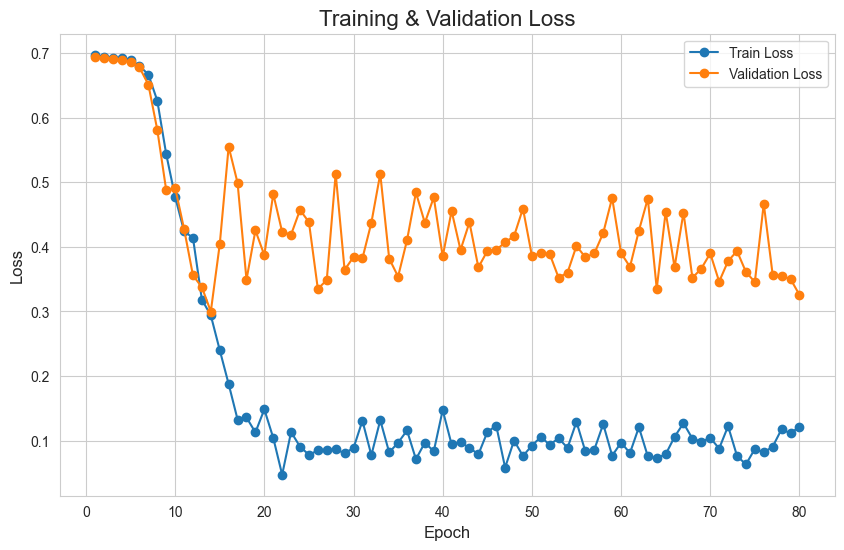

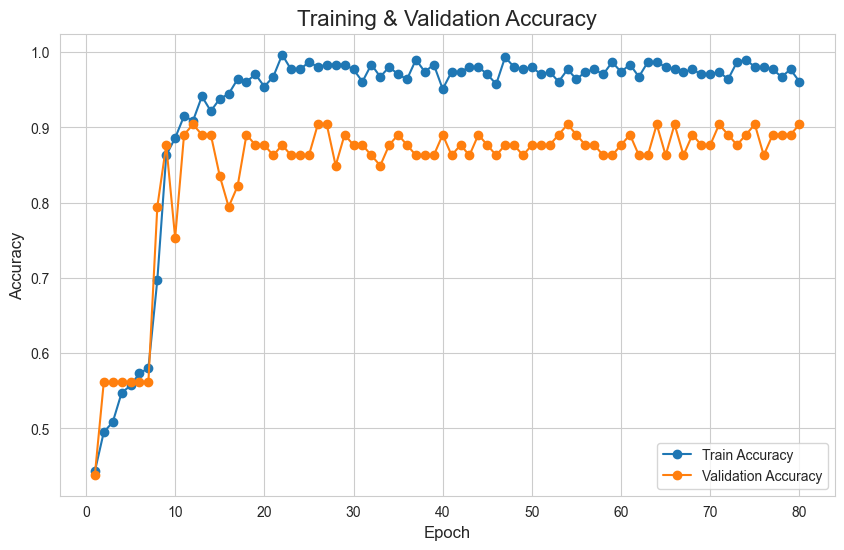

In [16]:
#if not history.empty:
PLOT_PATH = r'E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\training_results\plots'
plot_training_curves(history, PLOT_PATH)

# INFERENCE

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
def evaluate_model(model, test_loader, criterion, device, class_names):
    """Evaluates the model on the test set and returns detailed metrics."""
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    test_loss, total_samples = 0.0, 0

    # Benchmarking
    if device.type == 'cuda': torch.cuda.reset_peak_memory_stats(device)
    inference_times = []

    with torch.no_grad():
        for videos, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
            videos, labels = videos.to(device), labels.to(device)

            start_time = time.time()
            outputs = model(videos)
            if device.type == 'cuda': torch.cuda.synchronize()
            end_time = time.time()
            inference_times.append((end_time - start_time) * 1000) # in ms

            loss = criterion(outputs, labels)
            test_loss += loss.item() * videos.size(0)

            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            all_targets.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            total_samples += labels.size(0)

    # Compile results
    avg_test_loss = test_loss / total_samples
    all_targets, all_preds = np.array(all_targets), np.array(all_preds)
    all_probs = np.concatenate(all_probs, axis=0)

    test_accuracy = (all_preds == all_targets).sum() / total_samples
    report_str = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
    cm_array = confusion_matrix(all_targets, all_preds)

    results = {
        'num_samples_processed': total_samples,
        'inference_time_per_batch_ms': np.mean(inference_times),
        'peak_gpu_memory_mb': torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 'N/A',
        'test_loss': avg_test_loss,
        'test_accuracy': test_accuracy,
        'all_targets': all_targets,
        'pred_labels': all_preds,
        'pred_probs': all_probs,
        'classification_report_str': report_str,
        'confusion_matrix_array': cm_array,
    }

    # Print summary
    print("\n--- Test Set Evaluation Summary ---")
    print(f"  Samples Processed: {results['num_samples_processed']}")
    print(f"  Avg. Inference Time / Batch: {results['inference_time_per_batch_ms']:.2f} ms")
    print(f"  Peak GPU Memory: {results['peak_gpu_memory_mb']:.2f} MB")
    print(f"  Test Loss: {results['test_loss']:.4f}")
    print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
    print("\nClassification Report:")
    print(results['classification_report_str'])
    print("\nConfusion Matrix:")
    print(pd.DataFrame(results['confusion_matrix_array'], index=class_names, columns=class_names))
    print("-----------------------------------")

    return results

In [19]:
def plot_confusion_matrix(cm_array, class_names, save_path):
    """Plots and saves a confusion matrix."""
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 16})
    plt.title('Confusion Matrix', fontsize=20)
    plt.ylabel('True Label', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Confusion matrix plot saved to {save_path}")
    plt.show()



In [20]:
def display_and_save_advanced_metrics(cm, class_names, save_path):
    """Calculates, displays, and saves advanced metrics to an Excel file."""
    metrics_data = []
    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        accuracy = (tp + tn) / cm.sum() if cm.sum() > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

        metrics_data.append({
            'Class': class_name,
            'Accuracy (%)': accuracy * 100,
            'Precision (%)': precision * 100,
            'Sensitivity (Recall) (%)': sensitivity * 100,
            'Specificity (%)': specificity * 100,
            'F1-Score (%)': f1_score * 100,
        })

    metrics_df = pd.DataFrame(metrics_data)

    # Calculate weighted averages
    support = cm.sum(axis=1)
    weighted_avg = {
        'Class': 'Weighted Avg.',
        'Accuracy (%)': (metrics_df['Accuracy (%)'] * support).sum() / support.sum(),
        'Precision (%)': (metrics_df['Precision (%)'] * support).sum() / support.sum(),
        'Sensitivity (Recall) (%)': (metrics_df['Sensitivity (Recall) (%)'] * support).sum() / support.sum(),\
        'F1-Score (%)': (metrics_df['F1-Score (%)'] * support).sum() / support.sum(),
        'Specificity (%)': (metrics_df['Specificity (%)'] * support).sum() / support.sum()
        
    }
    metrics_df = pd.concat([metrics_df, pd.DataFrame([weighted_avg])], ignore_index=True)

    print("\n--- Advanced Performance Metrics ---")
    print(metrics_df.to_string(index=False, float_format="%.2f"))

    # Save to Excel
    metrics_df.to_excel(save_path, index=False, sheet_name='Advanced_Metrics')
    print(f"\nAdvanced metrics saved to Excel file: {save_path}")
    return metrics_df

In [21]:
BASE_DATA_DIR = r'E:\Morshedul\CoronarDominance\content\OCCLUSION_DATA\RCA\Data'
FOLD = 'fold_1'
TEST_DIR = os.path.join(BASE_DATA_DIR, 'Test', FOLD)
OUTPUT_DIR = r'E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\testing_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [22]:
# Model Architecture Settings
# BACKBONE: 'resnet18', 'densenet121', 'efficientnet_b0', 'mobilenet_v2', 'vit_b_16'
BACKBONE_NAME = 'mobilenet_v2' 
# SEQUENTIAL_MODEL: 'lstm', 'gru', 'transformer'
SEQUENTIAL_MODEL = 'lstm'
IS_GRAYSCALE = True # Set to True for 1-channel grayscale images
SEQUENCE_LENGTH  = 15
# Hyperparameters
BATCH_SIZE = 2 # Smaller batch size for local testing
NUM_CLASSES = 2
NUM_WORKERS = 0 # Adjust based on your system's capabilities
CHECKPOINT_PATH = r'E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\training_results\mobilenetv2_LSTM_best_model.pth'
USE_CHECKPOINTING = True if 'densenet' in BACKBONE_NAME else False

In [23]:
MEAN, STD = 0.5461, 0.1453
data_transforms = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[MEAN], std=[STD])
    ])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Dataloaders ---
print("\nSetting up datasets...")
input_channels = 1 if IS_GRAYSCALE else 3
test_dataset = VideoFrameDataset(TEST_DIR, SEQUENCE_LENGTH, data_transforms, IS_GRAYSCALE)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Test samples: {len(test_dataset)}")
    

Using device: cuda

Setting up datasets...
Found 107 videos in E:\Morshedul\CoronarDominance\content\OCCLUSION_DATA\RCA\Data\Test\fold_1.
Test samples: 107


In [24]:

#--- Load Model ---
print("\nLoading model for inference...")
model = VideoClassifier(
    num_classes=2, backbone_name=BACKBONE_NAME, input_channels=input_channels,
    sequential_model_type=SEQUENTIAL_MODEL, hidden_dim=128, num_sequential_layers=5, bidirectional=False,use_checkpointing=USE_CHECKPOINTING
).to(device)

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
print(f"Model weights loaded from {CHECKPOINT_PATH}")


Loading model for inference...
Loading backbone: mobilenet_v2
Backbone 'mobilenet_v2' loaded. Feature dimension: 1280. Input channels: 1.
Model weights loaded from E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\training_results\mobilenetv2_LSTM_best_model.pth


In [25]:
criterion = nn.CrossEntropyLoss()

In [26]:
print("\n--- Starting Final Evaluation on Test Set ---")
if len(test_loader.dataset) > 0:
    eval_results = evaluate_model(model, test_loader, criterion, device, test_dataset.classes)
    
else:
    print("Test dataset is empty. Skipping final evaluation.")



--- Starting Final Evaluation on Test Set ---


Evaluating on Test Set: 100%|█████████████████████████████| 54/54 [00:24<00:00,  2.20it/s]


--- Test Set Evaluation Summary ---
  Samples Processed: 107
  Avg. Inference Time / Batch: 82.12 ms
  Peak GPU Memory: 1677.94 MB
  Test Loss: 0.3962
  Test Accuracy: 0.8318

Classification Report:
              precision    recall  f1-score   support

 nonoccluded     0.8596    0.8305    0.8448        59
    occluded     0.8000    0.8333    0.8163        48

    accuracy                         0.8318       107
   macro avg     0.8298    0.8319    0.8306       107
weighted avg     0.8329    0.8318    0.8320       107


Confusion Matrix:
             nonoccluded  occluded
nonoccluded           49        10
occluded               8        40
-----------------------------------


Confusion matrix plot saved to E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\testing_results\occ_cm.png


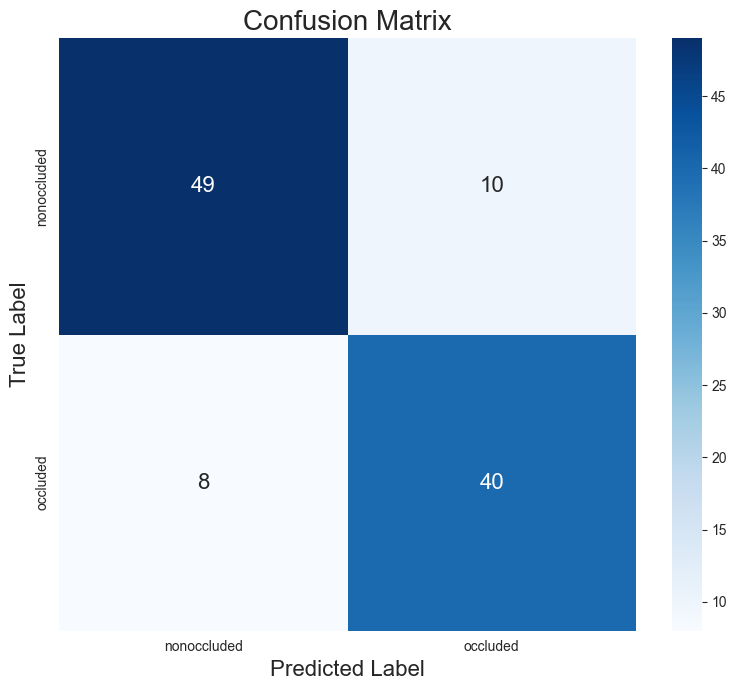

In [27]:
CM_PLOT_PATH = r'E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\testing_results\occ_cm.png'
plot_confusion_matrix(eval_results['confusion_matrix_array'], test_dataset.classes, CM_PLOT_PATH)

In [28]:
METRICS_EXCEL_PATH = r"E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\testing_results\occ_metrics.xlsx"
display_and_save_advanced_metrics(eval_results['confusion_matrix_array'], test_dataset.classes, METRICS_EXCEL_PATH)


--- Advanced Performance Metrics ---
        Class  Accuracy (%)  Precision (%)  Sensitivity (Recall) (%)  Specificity (%)  F1-Score (%)
  nonoccluded         83.18          85.96                     83.05            83.33         84.48
     occluded         83.18          80.00                     83.33            83.05         81.63
Weighted Avg.         83.18          83.29                     83.18            83.21         83.20

Advanced metrics saved to Excel file: E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\testing_results\occ_metrics.xlsx


,Class,Accuracy (%),Precision (%),Sensitivity (Recall) (%),Specificity (%),F1-Score (%)
0,nonoccluded,83.17757,85.964912,83.050847,83.333333,84.482759
1,occluded,83.17757,80.000000,83.333333,83.050847,81.632653
2,Weighted Avg.,83.17757,83.289064,83.177570,83.206611,83.204207
